# Algoritmo Metropolis-Hastings

Suponga una variable aleatoria $X = (X_1, X_2)$ con una distribucion de probabilidad $f(x_1, x_2)$ dada por 
$$
f(x_1, x_2) = \frac{\pi(x_1, x_2)}{Z}
$$

donde

$$
\pi(x_1, x_2) = \exp\left(-\frac{x_1^2 x_2^2 + x_1^2 + x_2^2 - 8x_1 - 8x_2}{2}\right)
$$

$$
Z = \int_{R^2} \pi(x_1,x_2) dx_1 dx_2
$$

Es posible aproximar la funcion $f$ sin necesidad de calcular la constante de normalización $Z$ utilizando el metodo de Monte Carlo vía Cadenas de Markov mediante el algoritmo de Metropolis-Hastings. Para esto, se construye una cadena de Markov con probabilidad de transición P dada por

$$
P(y|x) = q(y|x)\alpha(x,y)
$$

con $x = (x_1, x_2)$ (y analogamente para $y$), donde $q$ es una distribucion de probabilidad arbitraria que cubre el soporte de $f$ (una normal multivariada en este ejemplo) y $\alpha$ una probabilidad de aceptacion definida como

$$
\alpha(x,y) = \min\left\{1, \frac{\pi(y)q(x|y)}{\pi(x)q(y|x)}\right\}
$$

En este caso, al ser $q$ la funcion normal multivariada, $q(y|x) = q(x|y)$, por lo que

$$
\alpha(x,y) = \min\left\{1, \frac{\pi(y)}{\pi(x)}\right\}
$$

Esto garantiza que la cadena generada sea reversible (cumpliendo con la condición de balance detallado) y, por lo tanto, tenga como distribución estacionaria (o límite) a la distribución objetivo $f(x_1, x_2)$.

Asi, por el teorema ergodico y el teorema limite para cadenas de Markov, al correr la cadena y tras un periodo de calentamiento, cada paso sera una muestra de dicha distribucion.

In [20]:
import numpy as np

# Funcion pi(x)
def pi(x):
    x_1 = x[0]
    x_2 = x[1]

    return np.exp(-(x_1**2 * x_2**2 + x_1**2 + x_2**2 - 8*x_1 - 8*x_2)/2)

# Estado inicial
x_inicial = [1.25,3.5]

# Numero de pasos/iteraciones
N_iter = 12500

# Tamaño de los saltos
saltos = [0.1, 0.1]

x = np.zeros((2, N_iter + 1))
x[:,0] = x_inicial


for i in range(1, N_iter+1):
    # Generamos y ~ q(y|x), q(y|x) como una distribucion normal
    y = x[:,i-1] + np.random.normal(0, saltos, 2)

    # Calculamos la probabilidad alpha
    alpha = pi(y) / pi(x[:,i-1]) # Como q(y|x) es simetrica, se cancela

    # Aceptamos o rechazamos la transicion
    u = np.random.uniform(0, 1)
    if u < alpha:
        x[:,i] = y
    else:
        x[:,i] = x[:,i-1]

# Cortamos los valores generados de calentamiento
x = x[:, 2500:]


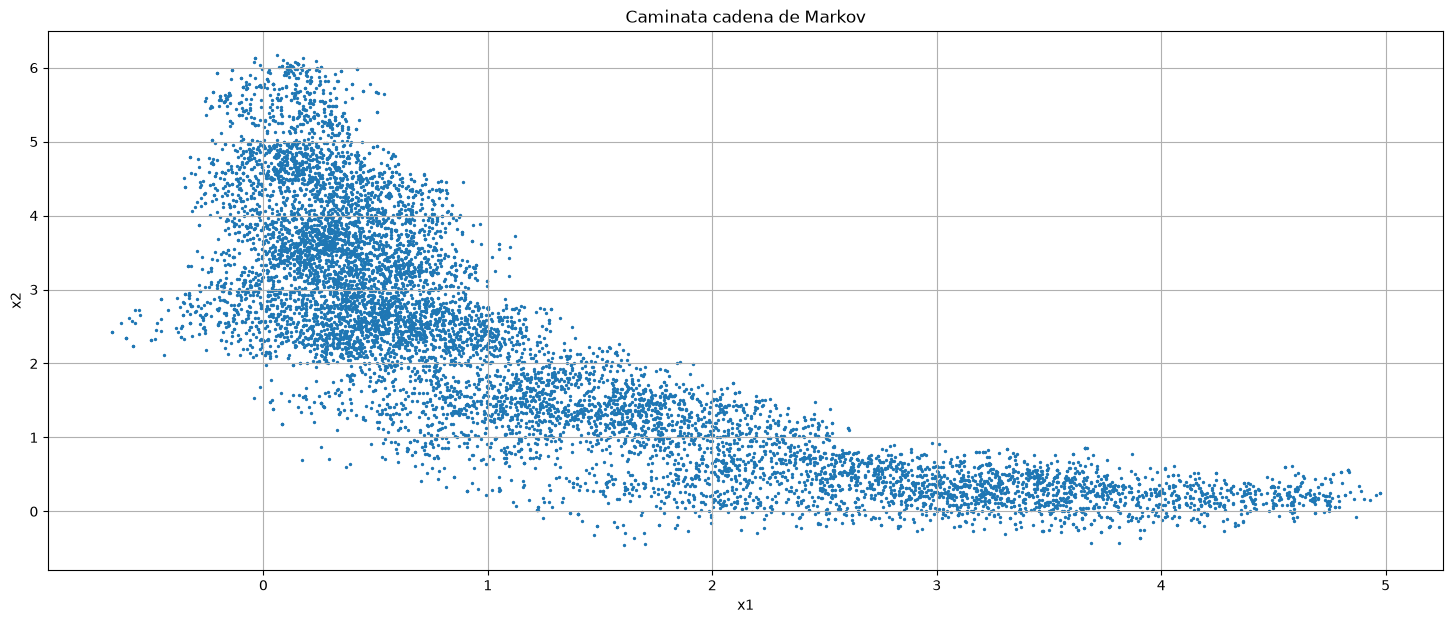

In [21]:
from matplotlib import pyplot as plt

# Se usa plt.subplots para inicializar la figura y los ejes
fig, ax = plt.subplots(figsize=(18, 7))

# Se crea el gráfico de dispersión con las coordenadas
ax.scatter(x[0].tolist(), x[1].tolist(), color='tab:blue', s=2)
ax.set_xlabel('x1') # Etiqueta del eje X
ax.set_ylabel('x2') # Etiqueta del eje Y
ax.set_title('Caminata cadena de Markov') # Título de la gráfica
ax.grid(True) # Se activa la cuadrícula

plt.show()
